In [1]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
os.getcwd()
os.listdir()

['.ipynb_checkpoints',
 'outputs',
 'sale.db',
 'sales.db',
 'sales_chart.png',
 'sales_data.csv',
 'sale_chart.png',
 'SQL_IN_PYTHON.ipynb']

In [3]:
df = pd.read_csv("sales_data.csv",encoding='latin1')
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
conn = sql.connect("sales.db")

In [5]:
df.to_sql("sales",conn,if_exists='replace',index=False)

2823

In [6]:
pd.read_sql("select * from sales",conn)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,None,NYC,NY,10022,USA,None,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,None,Reims,None,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,None,Paris,None,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,None,Pasadena,CA,90003,USA,None,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,None,San Francisco,CA,None,USA,None,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",None,Madrid,None,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,None,Oulu,None,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",None,Madrid,None,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,None,Toulouse,None,31000,France,EMEA,Roulet,Annette,Small


In [7]:
query1 = "SELECT SUM(QUANTITYORDERED) AS total_quantity FROM sales"
pd.read_sql(query1, conn)


,total_quantity
0,99067


In [8]:
query2 = """
SELECT SUM(QUANTITYORDERED*PRICEEACH) AS total_revenue
FROM sales
"""
pd.read_sql(query2, conn)

,total_revenue
0,8290886.79


In [9]:
total_qty = pd.read_sql(query1, conn)
total_rev = pd.read_sql(query2, conn)

print("Total Quantity Sold:", total_qty["total_quantity"][0])
print("Total Revenue: ₹", total_rev["total_revenue"][0])


Total Quantity Sold: 99067
Total Revenue: ₹ 8290886.79


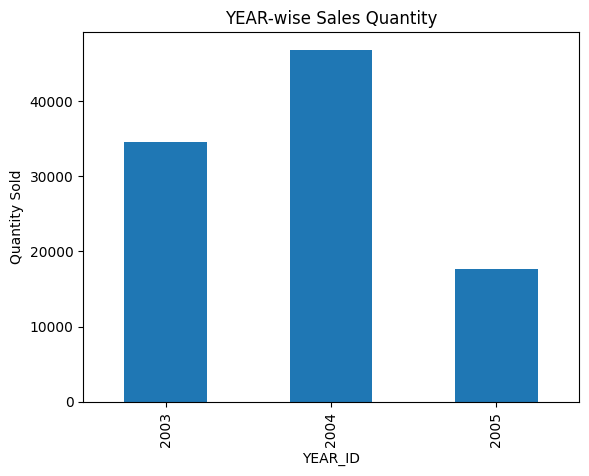

In [10]:
chart_query = """
SELECT YEAR_ID, SUM(QUANTITYORDERED) AS quantity_sold
FROM sales
GROUP BY YEAR_ID
"""
chart_df = pd.read_sql(chart_query, conn)
chart_df
chart_df.plot(
    x="YEAR_ID",
    y="quantity_sold",
    kind="bar",
    legend=False
)
plt.xlabel("YEAR_ID")
plt.ylabel("Quantity Sold")
plt.title("YEAR-wise Sales Quantity")
plt.savefig("sales_chart.png")  # saves image
plt.show()


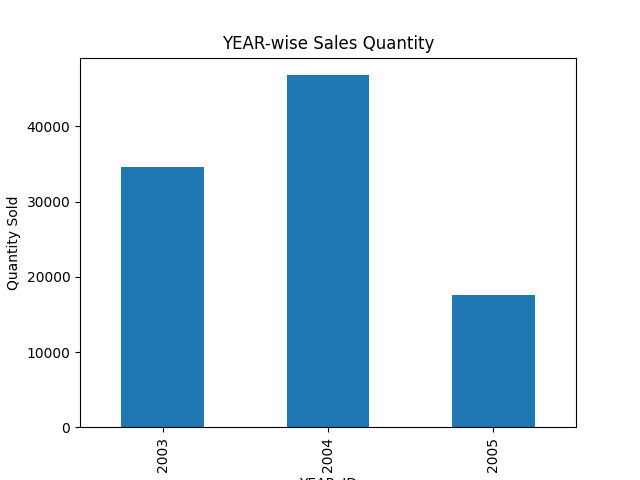

In [11]:
from IPython.display import Image, display
display(Image(filename="sales_chart.png"))


In [12]:
conn.close()

In [13]:
con=sql.connect("sale.db")

In [14]:
create_table_sql = """
CREATE TABLE IF NOT EXISTS sale (
    product TEXT,
    quantity INTEGER,
    price REAL
);
"""
con.execute(create_table_sql)


In [15]:
insert_sql = """
INSERT INTO sale (product, quantity, price)
VALUES (?, ?, ?)
"""
con.executemany(insert_sql, [
    ("Laptop", 5, 50000),
    ("Mobile", 10, 20000)
])
con.commit()


In [16]:
df = pd.read_sql("SELECT * FROM sale", con)
df

,product,quantity,price
0,Laptop,5,50000.0
1,Mobile,10,20000.0
2,Laptop,5,50000.0
3,Mobile,10,20000.0


In [17]:
query1 = "SELECT SUM(quantity) AS total_quantity FROM sale"
query2 = """SELECT SUM(quantity*price) AS total_revenue FROM sale"""
total_qty = pd.read_sql(query1, con)
total_rev = pd.read_sql(query2, con)

print("Total Quantity Sold:", total_qty["total_quantity"][0])
print("Total Revenue: ₹", total_rev["total_revenue"][0])


Total Quantity Sold: 30
Total Revenue: ₹ 900000.0


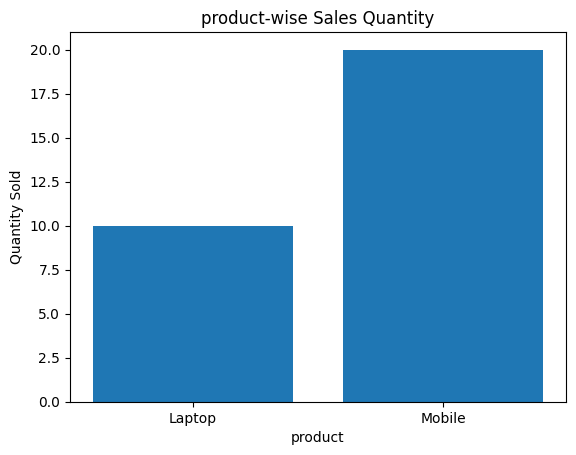

In [18]:
chart_query = """
SELECT product, SUM(quantity) AS quantity_sold
FROM sale
GROUP BY product
"""
chart_df = pd.read_sql(chart_query, con)

plt.bar(chart_df['product'],chart_df['quantity_sold'])
plt.xlabel("product")
plt.ylabel("Quantity Sold")
plt.title("product-wise Sales Quantity")
plt.savefig("sale_chart.png")  # saves image
plt.show()


In [19]:
con.close()